# 08 — Energy-Waste Detection (Final Audit)

Translates the analysis into actionable insight: which hours of the year
show **high consumption with low occupancy** — i.e., the kind of waste
that Dascalaki et al. found in Mediterranean campuses.


**Input:** `data/processed/df_ml_ready.csv`
**Output:** `outputs/reports/energy_audit.txt`


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PROCESSED = Path('../data/processed')
REPORTS = Path('../outputs/reports')
FIGURES = Path('../outputs/figures')
REPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
df_ml = pd.read_csv(DATA_PROCESSED / 'df_ml_ready.csv')
print(f"Loaded dataset: {df_ml.shape}")


Loaded dataset: (8773, 21)


## 1. Derive thresholds from the data

In [3]:
# "Empty" = occupancy under the 10th percentile.
# This isolates only hours genuinely without people.
UMBRAL_WIFI_VACIO = df_ml['Ocupacion_Simulada'].quantile(0.10)

# "High consumption" = median consumption when the building is operational.
# An empty building should not consume as much as an occupied one.
mediana_normal = df_ml.loc[
    df_ml['Ocupacion_Simulada'] > df_ml['Ocupacion_Simulada'].median(),
    'Consumo_kWh'
].median()
UMBRAL_CONSUMO_ALTO = mediana_normal

# "Justified phantom load" = 25th percentile of consumption during empty hours.
# Below this is just servers, fridges, emergency lighting — that is unavoidable.
CONSUMO_FANTASMA = df_ml.loc[
    df_ml['Ocupacion_Simulada'] <= UMBRAL_WIFI_VACIO,
    'Consumo_kWh'
].quantile(0.25)

print("📐 Thresholds derived from the data:")
print(f"   Empty-building threshold:    < {UMBRAL_WIFI_VACIO:.0f} people  (P10 of occupancy)")
print(f"   High-consumption threshold:  > {UMBRAL_CONSUMO_ALTO:.0f} kWh   (median operative consumption)")
print(f"   Justified phantom load:      = {CONSUMO_FANTASMA:.0f} kWh   (P25 of empty-hour consumption)")


📐 Thresholds derived from the data:
   Empty-building threshold:    < 0 people  (P10 of occupancy)
   High-consumption threshold:  > 277 kWh   (median operative consumption)
   Justified phantom load:      = 98 kWh   (P25 of empty-hour consumption)


## 2. Economic parameters (cited)

In [4]:
# Mean tertiary-sector electricity price in Spain 2024 (Red Eléctrica de España)
PRECIO_KWH_EUROS = 0.15

# Conservative recovery rate: occupancy-driven HVAC studies typically report
# 20–40% savings (Martani et al. 2012, Alishahi et al. 2022). We assume 30%.
TASA_RECUPERACION = 0.30

print(f"€/kWh:               {PRECIO_KWH_EUROS:.2f}")
print(f"Recovery rate (HVAC): {TASA_RECUPERACION:.0%}")


€/kWh:               0.15
Recovery rate (HVAC): 30%


## 3. Detect leak hours

In [5]:
fugas = df_ml[
    (df_ml['Ocupacion_Simulada'] <= UMBRAL_WIFI_VACIO) &
    (df_ml['Consumo_kWh'] >= UMBRAL_CONSUMO_ALTO)
].copy()

fugas['kWh_Derrochados'] = (fugas['Consumo_kWh'] - CONSUMO_FANTASMA).clip(lower=0)

total_kwh = fugas['kWh_Derrochados'].sum()
horas_perdidas = len(fugas)
coste_eur = total_kwh * PRECIO_KWH_EUROS
ahorro_potencial = coste_eur * TASA_RECUPERACION

print(f"🔍 Leak hours detected: {horas_perdidas:,} / year")
print(f"⚡ Wasted energy:        {total_kwh:>10,.2f} kWh")
print(f"💰 Cost of waste:        {coste_eur:>10,.2f} €")
print(f"✅ Potential savings:    {ahorro_potencial:>10,.2f} € / year")


🔍 Leak hours detected: 220 / year
⚡ Wasted energy:         49,551.00 kWh
💰 Cost of waste:          7,432.65 €
✅ Potential savings:      2,229.79 € / year


## 4. Visualize: where in the (occupancy, consumption) plane are the leaks?

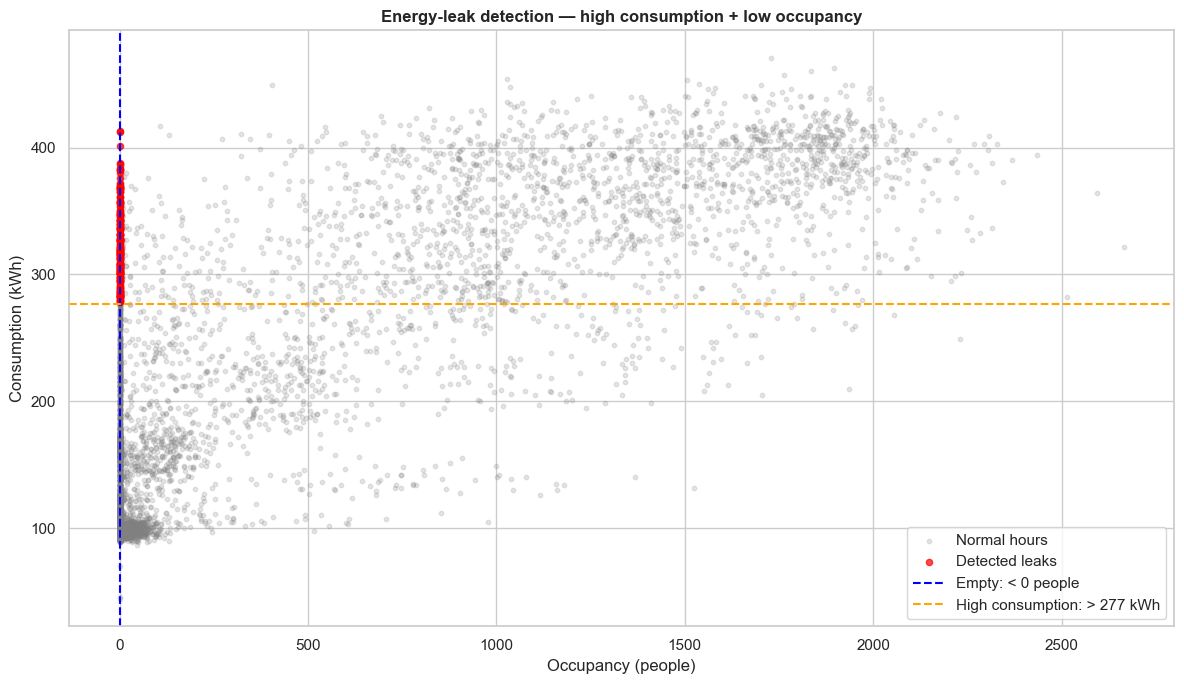

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(df_ml['Ocupacion_Simulada'], df_ml['Consumo_kWh'],
           alpha=0.2, s=10, color='gray', label='Normal hours')
ax.scatter(fugas['Ocupacion_Simulada'], fugas['Consumo_kWh'],
           alpha=0.7, s=20, color='red', label='Detected leaks')
ax.axvline(UMBRAL_WIFI_VACIO, color='blue', linestyle='--',
           label=f'Empty: < {UMBRAL_WIFI_VACIO:.0f} people')
ax.axhline(UMBRAL_CONSUMO_ALTO, color='orange', linestyle='--',
           label=f'High consumption: > {UMBRAL_CONSUMO_ALTO:.0f} kWh')
ax.set_title("Energy-leak detection — high consumption + low occupancy",
             fontweight='bold')
ax.set_xlabel("Occupancy (people)")
ax.set_ylabel("Consumption (kWh)")
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(FIGURES / 'energy_leaks.png', dpi=120)
plt.show()


## 5. Save executive report

In [7]:
report = f"""
═══════════════════════════════════════════════════════════════════
SMART CAMPUS ENERGY AUDIT — UPF POBLENOU 2024
═══════════════════════════════════════════════════════════════════

THRESHOLDS (derived from data, not arbitrary):
  Empty-building threshold:    < {UMBRAL_WIFI_VACIO:.0f} people  (P10 occupancy)
  High-consumption threshold:  > {UMBRAL_CONSUMO_ALTO:.0f} kWh   (median operative)
  Justified phantom load:      = {CONSUMO_FANTASMA:.0f} kWh   (P25 of empty hours)

ECONOMIC PARAMETERS:
  Electricity price:    {PRECIO_KWH_EUROS:.2f} €/kWh (REE 2024)
  Recovery rate (HVAC): {TASA_RECUPERACION:.0%} (Martani 2012, Alishahi 2022)

DETECTION RESULTS:
  Leak hours detected:   {horas_perdidas:,} / year
  Wasted energy total:   {total_kwh:,.2f} kWh
  Cost of waste:         {coste_eur:,.2f} €
  Potential savings:     {ahorro_potencial:,.2f} € / year

CONCLUSION:
  Integrating the predictive XGBoost model with the campus HVAC system
  could recover an estimated {ahorro_potencial:,.0f} € per year, addressing
  the same kind of waste pattern documented by Dascalaki et al. (2016)
  on Mediterranean campuses.
═══════════════════════════════════════════════════════════════════
"""

print(report)

with open(REPORTS / 'energy_audit.txt', 'w') as f:
    f.write(report)

print(f"✅ Report saved to {REPORTS / 'energy_audit.txt'}")



═══════════════════════════════════════════════════════════════════
SMART CAMPUS ENERGY AUDIT — UPF POBLENOU 2024
═══════════════════════════════════════════════════════════════════

THRESHOLDS (derived from data, not arbitrary):
  Empty-building threshold:    < 0 people  (P10 occupancy)
  High-consumption threshold:  > 277 kWh   (median operative)
  Justified phantom load:      = 98 kWh   (P25 of empty hours)

ECONOMIC PARAMETERS:
  Electricity price:    0.15 €/kWh (REE 2024)
  Recovery rate (HVAC): 30% (Martani 2012, Alishahi 2022)

DETECTION RESULTS:
  Leak hours detected:   220 / year
  Wasted energy total:   49,551.00 kWh
  Cost of waste:         7,432.65 €
  Potential savings:     2,229.79 € / year

CONCLUSION:
  Integrating the predictive XGBoost model with the campus HVAC system
  could recover an estimated 2,230 € per year, addressing
  the same kind of waste pattern documented by Dascalaki et al. (2016)
  on Mediterranean campuses.
═══════════════════════════════════════════